# Background Information

The game of soccer is continuous in time but decisions are discrete. We can treat a match as an ordered sequence of events: match = [e1, e2, ... ] where each event has its own structure and contextual field

The main research question I'd like to address is how we can leverage graph theory and network analysis combined with deep learning to analyze player similarity. Football passing structure can naturally be represented as a directed graph G = (V,E) where the set of nodes V represents players and E represents passes. In this EDA I hope to understand how all of the statsbomb data works together, and ultimately be able to model this graph as input for a graph neural network (GNN).

The statsbomb data has many tables and the following hierarchical structure:



├── data/
   
        ├── competitions.json          # Competition metadata

        ├── matches/                   # Match-level data

            └── {competition_id}/

                └── {season_id}.json   # Matches for specific competition-season

        ├── events/                    # Event-level data

            └── {match_id}.json        # Events for specific match

        ├── lineups/                   # Player lineup data

            └── {match_id}.json        # Lineups for specific match

        └── three-sixty/               # 360-degree tracking data
            └── {match_id}.json        # 360 data for specific match


The 360 data is not available for all matches. I closely followed the following blogpost, which was very helpful in navigating this complex dataset: https://medium.com/@lucascarrasquillaparra/complete-guide-on-working-with-the-statsbomb-open-data-dataset-a57c26d5852b

Some additional sources referenced: 
- https://paulminogue.com/posts/375ea85d-fc58-4c13-a9dc-5a45ba3c368f
- https://github.com/minoguep/graph_neural_networks/blob/master/graph_neural_network_data_preparation.ipynb
- https://www.youtube.com/watch?v=7JELX6DiUxQ
- https://www.nature.com/articles/s41467-024-45965-x


# Import Packages

In [ ]:
import json
from pathlib import Path
import pandas as pd
import os
import numpy as np
import calendar
import matplotlib.pyplot as plt
import json
import seaborn as sns         
from pathlib import Path       
from scipy import stats   
from mplsoccer import Pitch
from matplotlib.lines import Line2D
from collections import defaultdict
import networkx as nx
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# Exploring the competition-level data

Q: How "big" is the dataset? What is the scope?

In [2]:
root_dir = Path('statsbomb_data')
comp_path = root_dir / "data" / "competitions.json"
competitions_data = json.loads(comp_path.read_text(encoding="utf-8"))
competitions_df = pd.DataFrame(competitions_data)

comp_counts = competitions_df['competition_name'].value_counts()

print('=== COMPETITION-LEVEL DATA ANALYSIS ===')
print("Columns:", sorted(competitions_df.columns))

print("\n")
summary = {
    "total competitions": len(competitions_df),
    "competition types (unique)": competitions_df["competition_name"].nunique(),
    "season coverage (unique)": competitions_df["season_id"].nunique(),
    "competition gender breakdown": competitions_df["competition_gender"].value_counts(dropna=False).to_dict(),
    "geographic coverage":f"{competitions_df['country_name'].nunique()} countries",
    "temporal span" : f"{competitions_df['season_name'].min()} to {competitions_df['season_name'].max()}",
    "mean seasons per competition" : f"{comp_counts.mean():.2f}"
}

for k, v in summary.items():
    print(f"{k}: {v}")

print("\nSample rows:")
print(competitions_df.head(3))

=== COMPETITION-LEVEL DATA ANALYSIS ===
Columns: ['competition_gender', 'competition_id', 'competition_international', 'competition_name', 'competition_youth', 'country_name', 'match_available', 'match_available_360', 'match_updated', 'match_updated_360', 'season_id', 'season_name']


total competitions: 75
competition types (unique): 21
season coverage (unique): 48
competition gender breakdown: {'male': 67, 'female': 8}
geographic coverage: 13 countries
temporal span: 1958 to 2025
mean seasons per competition: 3.57

Sample rows:
   competition_id  season_id country_name        competition_name  \
0               9        281      Germany           1. Bundesliga   
1               9         27      Germany           1. Bundesliga   
2            1267        107       Africa  African Cup of Nations   

  competition_gender  competition_youth  competition_international  \
0               male              False                      False   
1               male              False        

Q: What does coverage (i.e. data) look like across competitions?

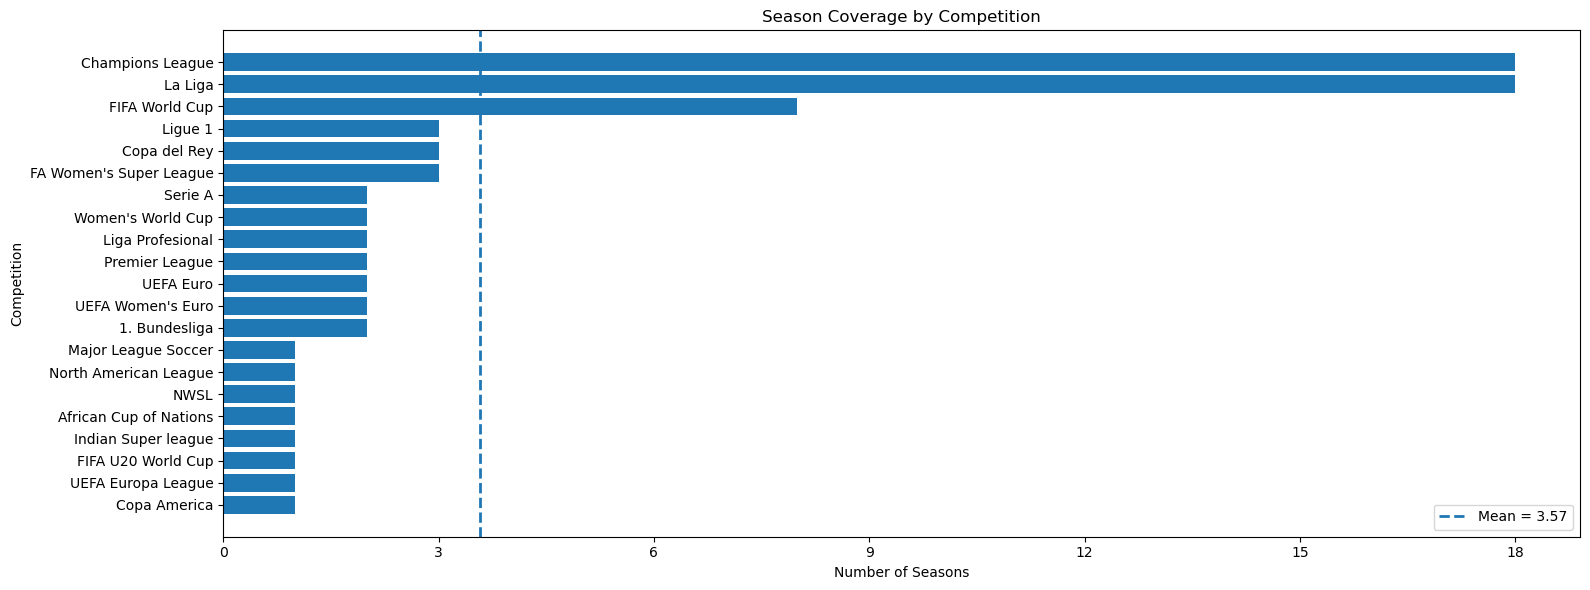

In [3]:
comp_counts = competitions_df["competition_name"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 6))

# bar plot
plt.barh(comp_counts.index, comp_counts.values)

# mean line
mean_count = comp_counts.mean()
plt.axvline(mean_count, linestyle='--', linewidth=2, label=f"Mean = {mean_count:.2f}")

# labels
plt.xlabel("Number of Seasons")
plt.ylabel("Competition")
plt.title("Season Coverage by Competition")
plt.xticks(rotation=90)
plt.legend()

max_x = comp_counts.max()
plt.xticks(np.arange(0, max_x + 3, 3))
plt.xticks(rotation=0)


# highest count on top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


Q: Which countries are represented?

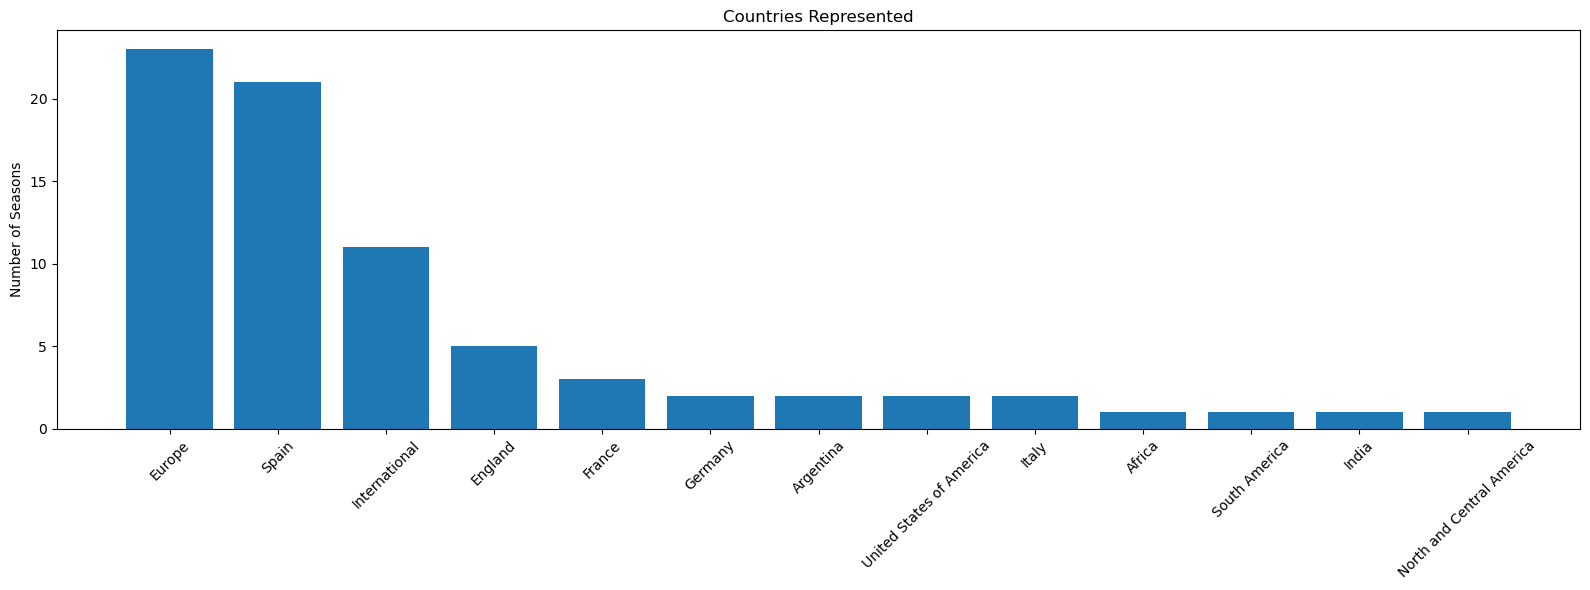

In [4]:
comp_counts = competitions_df["country_name"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 6))

# bar plot
plt.bar(comp_counts.index, comp_counts.values)

# labels
plt.ylabel("Number of Seasons")
plt.title("Countries Represented")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Q: Which competitions have 360 data availability? This is relevant because it provides the freeze-frame context of events, which we can use to create our graph networks.

In [5]:
has_360 = competitions_df.copy()[competitions_df['match_available_360'].notna()]
print('=== 360-DATA AVAILABILITY ANALYSIS ===')
print("Competitions with 360 data:")
for _, row in has_360.iterrows():
    print(f"  {row['competition_name']} {row['season_name']}")

has_360['year'] = has_360['season_name'].str[-4:].astype(float)
year_analysis = has_360.groupby('year').size()

print(f"\n360 Data Temporal Distribution:")
for year, count in year_analysis.items():
    print(f"  {int(year)}: {count} competitions")

=== 360-DATA AVAILABILITY ANALYSIS ===
Competitions with 360 data:
  1. Bundesliga 2023/2024
  FIFA World Cup 2022
  La Liga 2020/2021
  Ligue 1 2022/2023
  Ligue 1 2021/2022
  Major League Soccer 2023
  UEFA Euro 2024
  UEFA Euro 2020
  UEFA Women's Euro 2025
  UEFA Women's Euro 2022
  Women's World Cup 2023

360 Data Temporal Distribution:
  2020: 1 competitions
  2021: 1 competitions
  2022: 3 competitions
  2023: 3 competitions
  2024: 2 competitions
  2025: 1 competitions


# Exploring the match-level data

Some notes
- the data is JSON based, so the fields are nested objects i.e. dictionaries. We need to keep this in mind when parsing the data
- Match lists are stored by (competition_id, season_id)

Q: What does the match-data structure look like?

In [6]:
# sample loading of a single competition from La Liga 2020/21 season
competition_id = 11
season_id = 90
matches_path = Path(root_dir) / "data" / "matches" / str(competition_id) / f"{season_id}.json"

with open(matches_path, 'r', encoding='utf-8') as f:
        matches_data = json.load(f)
    
matches_df = pd.DataFrame(matches_data)

print("=== MATCH STRUCTURE ANALYSIS ===")
print(f"Competition Name: {matches_df['competition'][0]['competition_name']}, Country: {matches_df['competition'][0]['country_name']}")
print(f"Season: {matches_df['season'][0]['season_name']}")
print(f"Total matches: {len(matches_df)}")
print(f"Schema columns: {list(matches_df.columns)}")

sample_match = matches_df.iloc[10]
print(f"\nSample Match Metadata:")
print(f"  Match ID: {sample_match.get('match_id')}")
print(f"  Date: {sample_match.get('match_date')}")
print(f"  Kick-off: {sample_match.get('kick_off')}")
    
# Extract team information
home_team = sample_match.get('home_team', {})
away_team = sample_match.get('away_team', {})
print(f"  Home team: {home_team.get('home_team_name', 'Unknown')}")
print(f"  Away team: {away_team.get('away_team_name', 'Unknown')}")

# Extract score information
home_score = sample_match.get('home_score', {})
away_score = sample_match.get('away_score', {})
print(f"  Final Score: {home_score}-{away_score}")

# Temporal coverage
dates = pd.to_datetime(matches_df['match_date'])
print(f"\nTemporal Coverage:")
print(f"  Date range: {dates.min().date()} to {dates.max().date()}")
print(f"  Duration: {(dates.max() - dates.min()).days} days")


=== MATCH STRUCTURE ANALYSIS ===
Competition Name: La Liga, Country: Spain
Season: 2020/2021
Total matches: 35
Schema columns: ['match_id', 'match_date', 'kick_off', 'competition', 'season', 'home_team', 'away_team', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'metadata', 'match_week', 'competition_stage', 'stadium', 'referee']

Sample Match Metadata:
  Match ID: 3773552
  Date: 2021-01-03
  Kick-off: 21:00:00.000
  Home team: Huesca
  Away team: Barcelona
  Final Score: 0-1

Temporal Coverage:
  Date range: 2020-09-27 to 2021-05-16
  Duration: 231 days


Q: Are there any overall seasonality trends? Do matches tend to occur more frequently during certain parts of the year?

In [7]:
# aggregate all match data across all files
matches_dir = Path(root_dir) / "data" / "matches"
match_data = []

for subdir, dir, files in os.walk(matches_dir):
    for file in files:
        with open(os.path.join(subdir, file)) as json_file:
            matches = json.load(json_file)
            for match in matches:
                match_data.append(
                        {
                            'match_id': match['match_id'],
                            'match_date': match['match_date'],
                            'competition': match['competition']['competition_name'],
                            'season': match['season']['season_name'],
                            'home_team_id': match['home_team']['home_team_id'],
                            'home_team': match['home_team']['home_team_name'],
                            'away_team': match['away_team']['away_team_name'],
                            'away_team_id': match['away_team']['away_team_id'],
                            'home_score': match['home_score'],
                            'away_score': match['away_score'],
                        })
            
match_df = pd.DataFrame(match_data)

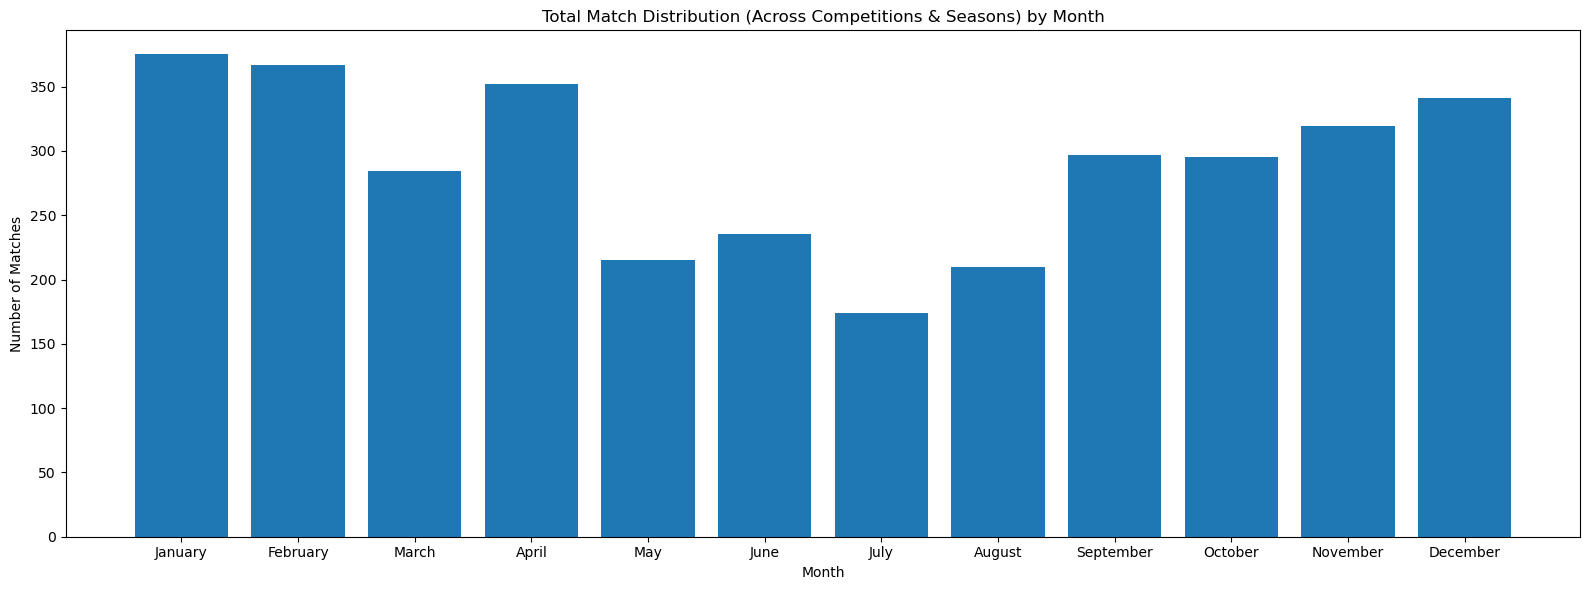

In [8]:
match_df['match_date'] = pd.to_datetime(match_df['match_date'])

monthly_counts = (
    match_df
        .assign(month=match_df['match_date'].dt.month)
        .groupby('month')
        .size()
)

plt.figure(figsize=(16, 6))
plt.bar(monthly_counts.index, monthly_counts.values)

plt.xlabel("Month")
plt.ylabel("Number of Matches")
plt.title("Total Match Distribution (Across Competitions & Seasons) by Month")

# map month number to month name
plt.xticks(
    ticks=monthly_counts.index,
    labels=[calendar.month_name[m] for m in monthly_counts.index],
    rotation=0
)

plt.tight_layout()
plt.show()


Q: What does the score differential look like across competitions? i.e. do some competitions tend to have larger differences between the home and away final score?

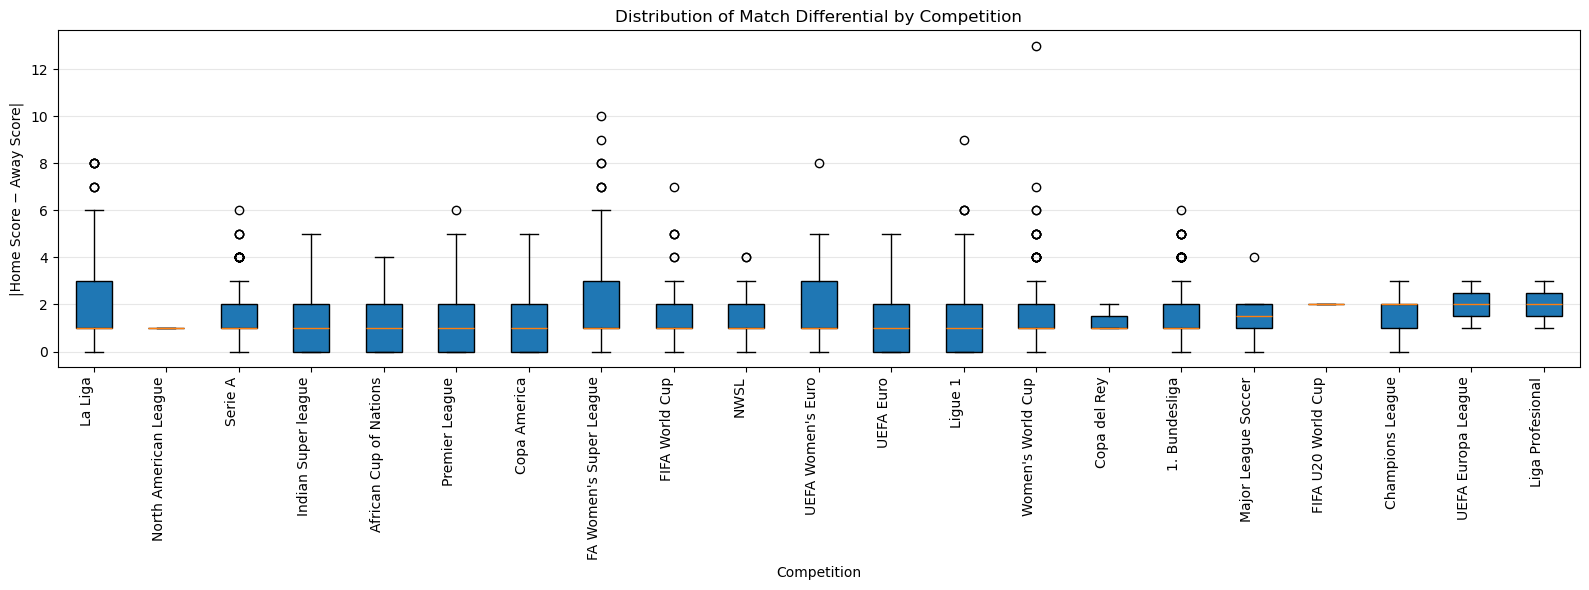

In [9]:
# get score differential
match_df['goal_diff'] = (match_df['home_score'] - match_df['away_score']).abs()

competitions = match_df['competition'].unique()

data = [
    match_df.loc[match_df['competition'] == comp, 'goal_diff']
    for comp in competitions
]



# sort by median goal difference
competitions, data = zip(*sorted(
    zip(competitions, data),
    key=lambda x: x[1].median()
))


plt.figure(figsize=(16, 6))

plt.boxplot(
    data,
    tick_labels=competitions,
    showfliers=True,
    patch_artist=True
)

plt.title('Distribution of Match Differential by Competition')
plt.ylabel('|Home Score − Away Score|')
plt.xlabel('Competition')

plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Exploring the event-level data

Some notes
- this is the core of the dataset; each match has a single event log. We can consider it as a time-ordered sequence of events, E_match = [e1, e2, ..., e_n] where e_n is the total number of recorded events for a given match
- since we will be modeling event-driven decisions, we want to understand what kind of events exist, which types dominate, and what kind of spatial information is available for each type of event

=== EVENT DATA STRUCTURE ANALYSIS ===
Match ID: 3773552
Competition: La Liga
Season: 2020/2021
Total events: 4179
Schema columns: ['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team', 'duration', 'tactics', 'related_events', 'player', 'position', 'location', 'pass', 'carry', 'under_pressure', 'ball_receipt', 'dribble', 'counterpress', 'duel', 'off_camera', 'out', 'clearance', 'ball_recovery', 'shot', 'goalkeeper', 'foul_won', 'block', 'interception', 'foul_committed', '50_50', 'substitution']
Unique event types: 24


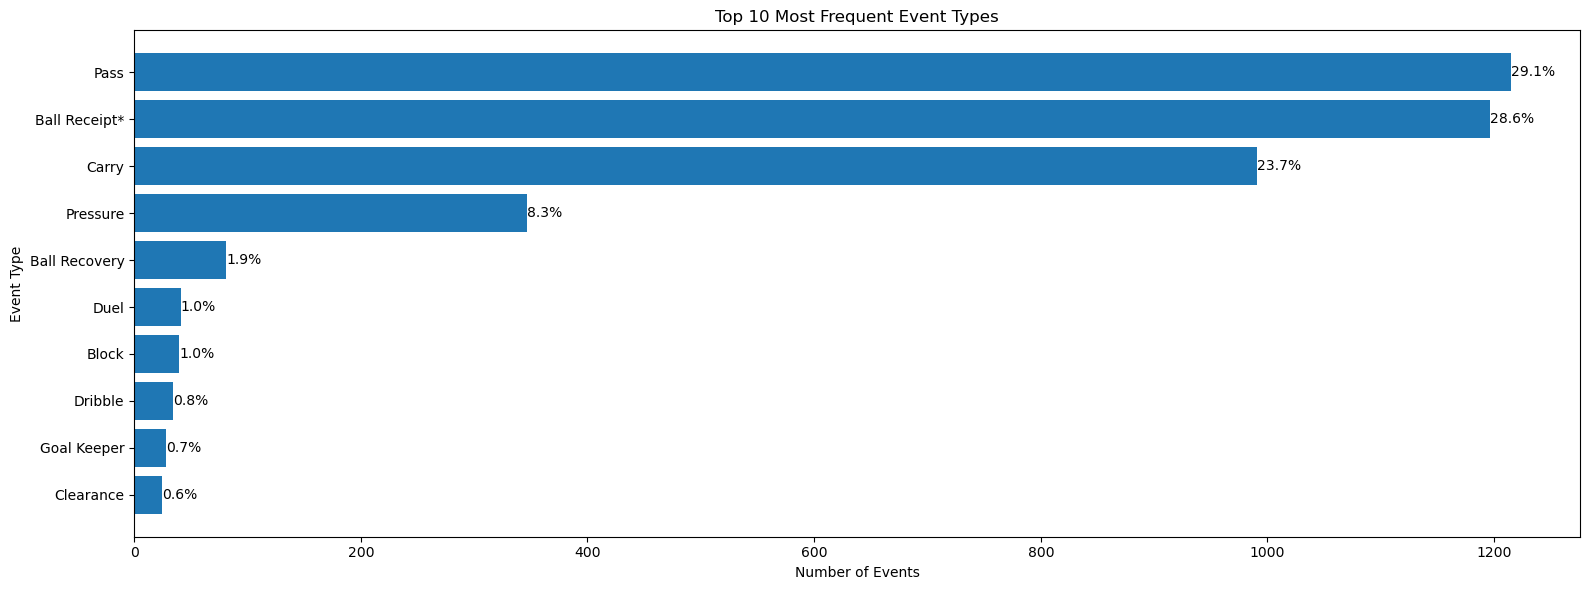

Events with location data: 4160 / 4179 (99.5%)
Time range covered: Minutes 0' to 92'
Number of periods: 2


In [19]:
match_id = '3773552'
events_path = root_dir / "data" / "events" / f"{match_id}.json"
    
   
with open(events_path, 'r', encoding='utf-8') as f:
    events_data = json.load(f)

events_df = pd.DataFrame(events_data)
match_info = match_df[match_df['match_id']==int(match_id)]

print("=== EVENT DATA STRUCTURE ANALYSIS ===")
print(f"Match ID: {match_id}")
print(f"Competition: {match_info['competition'].item()}")
print(f"Season: {match_info['season'].item()}")
print(f"Total events: {len(events_df)}")
print(f"Schema columns: {list(events_df.columns)}")

# Event type distribution analysis
event_types = events_df['type'].apply(
         lambda x: x['name'] if isinstance(x, dict) else str(x)
     ).value_counts()
    
print(f"Unique event types: {len(event_types)}")
 
top_10 = event_types.head(10)
total_events = len(events_df)

plt.figure(figsize=(16, 6))
plt.barh(top_10.index, top_10.values)

plt.xlabel("Number of Events")
plt.ylabel("Event Type")
plt.title("Top 10 Most Frequent Event Types")

# annotate bars with percentage
for i, v in enumerate(top_10.values):
    pct = (v / total_events) * 100
    plt.text(v, i, f"{pct:.1f}%", va='center')

# highest frequency at top
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Spatial data availability analysis
spatial_events = events_df[events_df['location'].notna()]
spatial_coverage = len(spatial_events) / len(events_df) * 100

print(f"Events with location data: {len(spatial_events)} / {len(events_df)} ({spatial_coverage:.1f}%)")

temporal_analysis = {
        'min_minute': events_df['minute'].min(),
        'max_minute': events_df['minute'].max(),
        'periods': events_df['period'].nunique() if 'period' in events_df.columns else 'Unknown'
    }
    
print(f"Time range covered: Minutes {temporal_analysis['min_minute']}' to {temporal_analysis['max_minute']}'")

print(f"Number of periods: {temporal_analysis['periods']}")


Q: Does event occurrence change over the match? i.e. is it more common to have more recorded events during certain parts of a match? Does half-time interfere with event occurence?

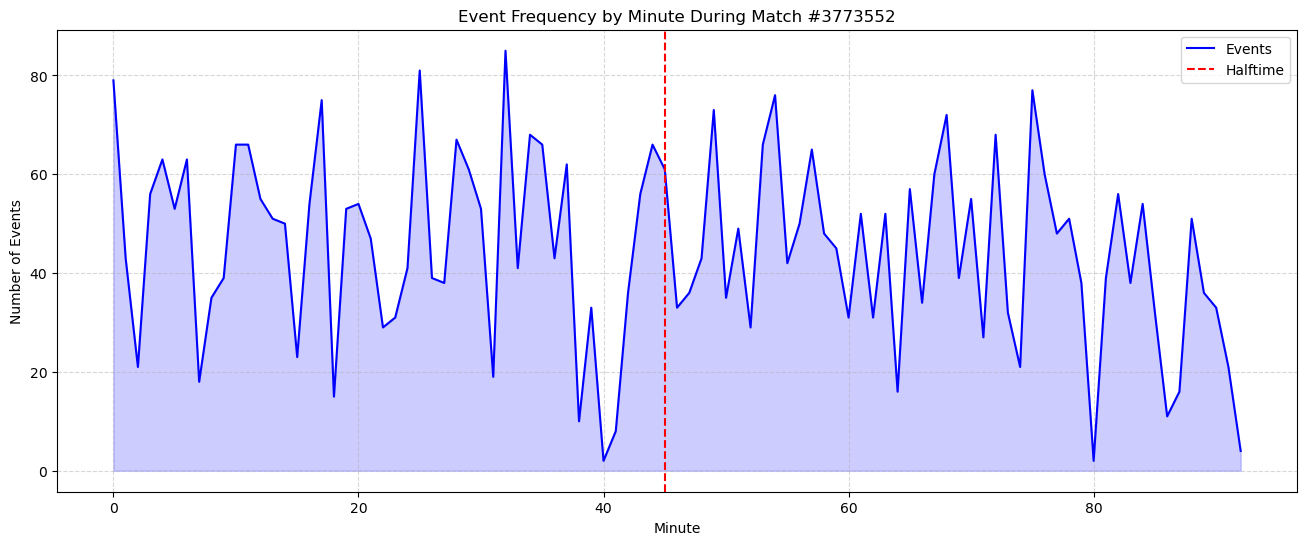

In [11]:
minute_counts = events_df['minute'].value_counts().sort_index()

plt.figure(figsize=(16,6))

plt.plot(minute_counts.index, minute_counts.values, color='blue', label='Events')
plt.fill_between(minute_counts.index, minute_counts.values, color='blue', alpha=0.2)

# Add halftime dashed vertical line
halftime = 45
plt.axvline(x=halftime, color='red', linestyle='--', label='Halftime')

plt.xlabel('Minute')
plt.ylabel('Number of Events')
plt.title(f'Event Frequency by Minute During Match #{match_id}')

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()


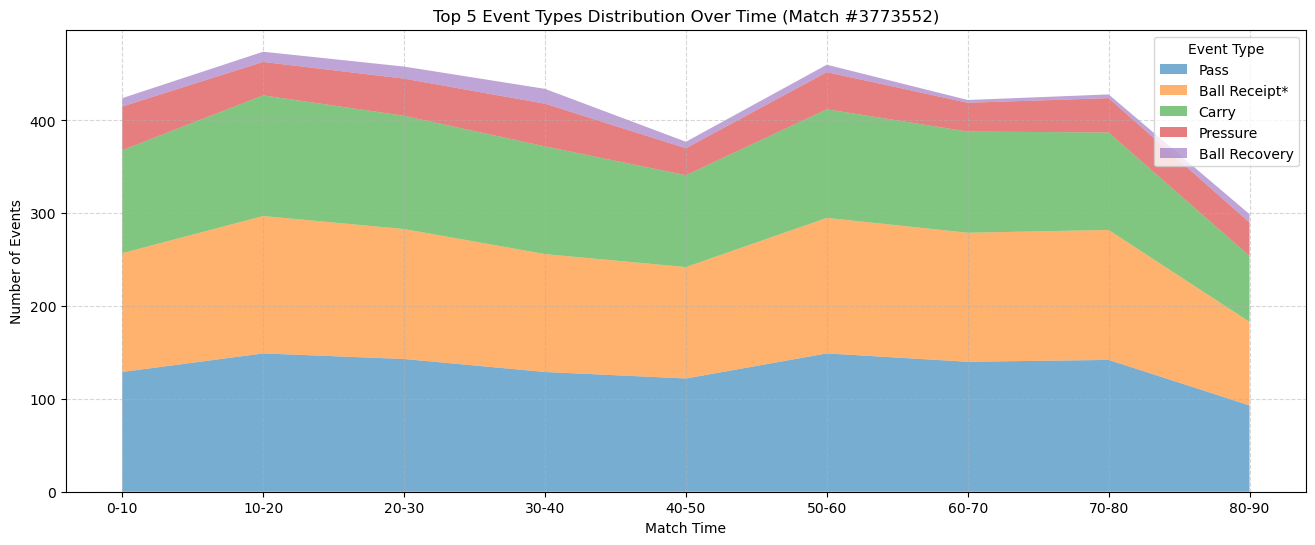

In [12]:
events_df['event_name'] = events_df['type'].apply(lambda x: x['name'])

# Get top 5 event types
top5_events = events_df['event_name'].value_counts().nlargest(5).index

# Filter to top 5 events
df_top5 = events_df.copy()[events_df['event_name'].isin(top5_events)]

# Create 10-minute bins
bins = np.arange(0, 91, 10)
labels = [f'{b}-{b+10}' for b in bins[:-1]]
df_top5['minute_bin'] = pd.cut(df_top5['minute'], bins=bins, labels=labels, right=False)

# Pivot table: rows = minute_bin, columns = event_name, values = counts
binned_counts = df_top5.groupby(['minute_bin', 'event_name'], observed=True).size().unstack(fill_value=0)


binned_counts = binned_counts.reindex(columns=top5_events, fill_value=0)

# Total events per bin
total_counts = binned_counts.sum(axis=1)

plt.figure(figsize=(16,6))

# Stackplot by event type
plt.stackplot(
    range(len(binned_counts.index)),
    [binned_counts[event].values for event in top5_events],
    labels=top5_events,
    alpha=0.6
)


# Labels and title
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.xlabel('Match Time')
plt.ylabel('Number of Events')
plt.title(f'Top 5 Event Types Distribution Over Time (Match #{match_id})')
plt.legend(title='Event Type')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


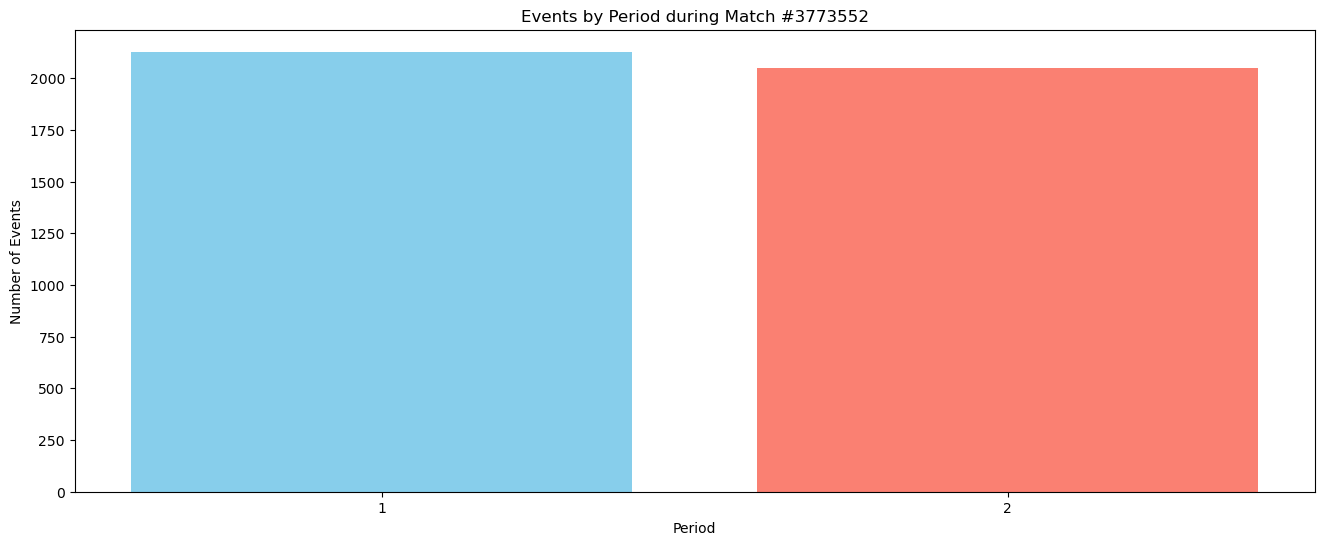

In [13]:
period_counts = events_df['period'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(16,6))
plt.bar(period_counts.index.astype(str), period_counts.values, color=['skyblue', 'salmon'])
plt.xlabel('Period')
plt.ylabel('Number of Events')
plt.title(f'Events by Period during Match #{match_id}')
plt.show()

Q: What does the event location distribution look like on the field?

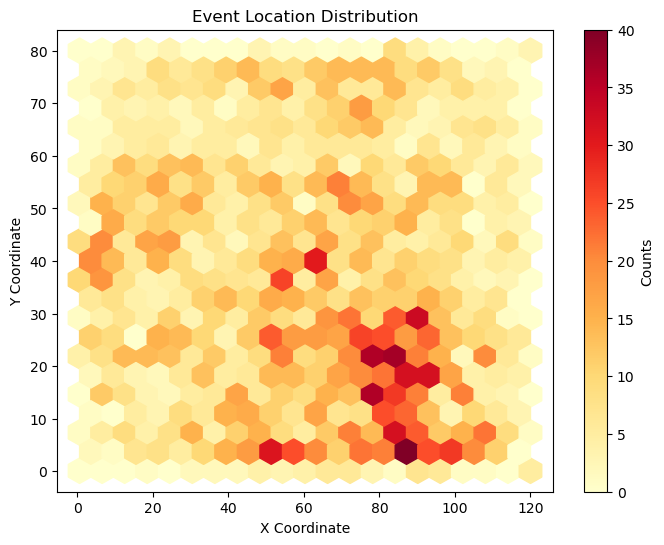

In [14]:
events_with_location = events_df.copy().dropna(subset=['location'])

# Split the location column into x and y
events_with_location[['x', 'y']] = pd.DataFrame(events_with_location['location'].tolist())

# Create hexbin plot
plt.figure(figsize=(8,6))
hb = plt.hexbin(events_with_location['x'], events_with_location['y'], gridsize=20, cmap='YlOrRd')
plt.colorbar(hb, label='Counts')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Event Location Distribution')
plt.show()

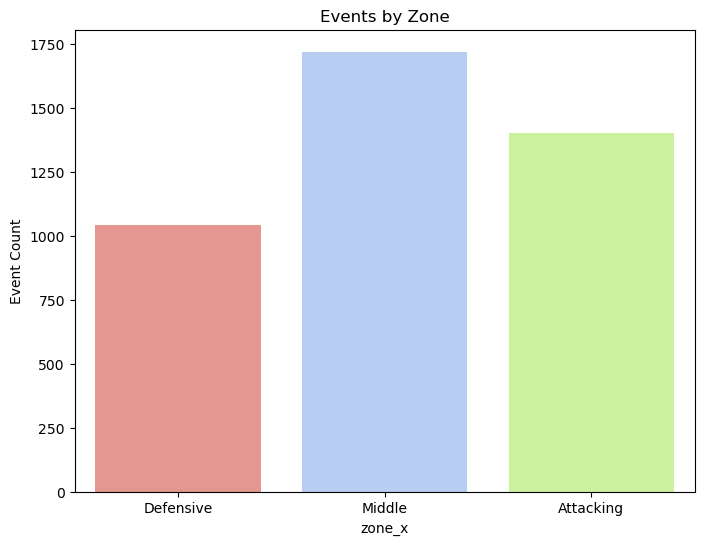

In [15]:
# split field intro 3 thirds- defensive, middle, attacking
locations = pd.DataFrame(events_with_location['location'].tolist(), columns=['x', 'y'])
locations['zone_x'] = pd.cut(locations['x'], bins=[0, 40, 80, 120], labels=['Defensive', 'Middle', 'Attacking'])
locations['zone_y'] = pd.cut(locations['y'], bins=[0, 27, 53, 80], labels=['Left', 'Center', 'Right'])

zone_distribution = locations.groupby(['zone_x', 'zone_y'], observed=True).size().reset_index(name='event_count')
zone_distribution['percentage'] = (zone_distribution['event_count'] / len(locations)) * 100

zone_order = ['Defensive', 'Middle', 'Attacking']
zone_counts = locations.groupby('zone_x', observed=True).size().reindex(zone_order)

plt.figure(figsize=(8,6))
sns.barplot(x=zone_counts.index, y=zone_counts.values, hue=zone_counts.index, palette=['#f28b82', '#aecbfa', '#ccff90'], legend=False)

plt.ylabel('Event Count')
plt.title('Events by Zone')
plt.show()

Q: What does the event distribution look like on a competition-level? i.e. choose a specific competition and season, and aggregate events across

=== EVENT DATA STRUCTURE ANALYSIS ===
Competition: FIFA World Cup
Season: 2022
Total events: 4179
Schema columns: ['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team', 'duration', 'tactics', 'related_events', 'player', 'position', 'location', 'pass', 'carry', 'under_pressure', 'ball_receipt', 'dribble', 'counterpress', 'duel', 'off_camera', 'out', 'clearance', 'ball_recovery', 'shot', 'goalkeeper', 'foul_won', 'block', 'interception', 'foul_committed', '50_50', 'substitution']
Unique event types: 24


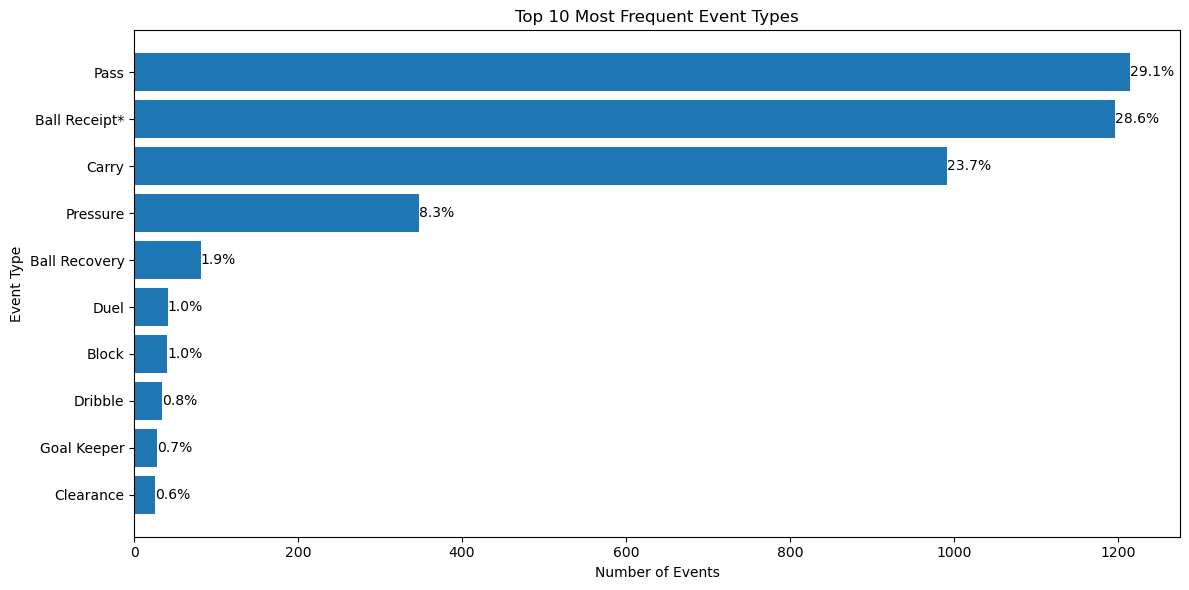

In [ ]:
# let's consider the 2022 fifa world cup
fifa22_id = match_df[(match_df['competition']==' ') & (match_df['season']=='2022')].match_id.to_list()

events_dir = root_dir / "data" / "events"

events_data = []
test = None
for filename in os.listdir(events_dir):
    if filename.endswith(".json"): 
        with open(os.path.join(events_dir, filename)) as json_file:
            match_id = int(filename[:-5])
            if match_id in fifa22_id:
                data = json.load(json_file)
                for event in data:

                            events_data.append(
                                {
                                    'match_id': match_id,
                                    'type': event["type"],    
                                }
                            )
# convert to dataframe
all_events_df = pd.DataFrame(events_data)

print("=== EVENT DATA STRUCTURE ANALYSIS ===")
print(f"Competition: FIFA World Cup")
print(f"Season: 2022")
print(f"Total events: {len(events_df)}")
print(f"Schema columns: {list(events_df.columns)}")

# Event type distribution analysis
event_types = events_df['type'].apply(
         lambda x: x['name'] if isinstance(x, dict) else str(x)
     ).value_counts()
    
print(f"Unique event types: {len(event_types)}")
 
top_10 = event_types.head(10)
total_events = len(events_df)

plt.figure(figsize=(12, 6))
plt.barh(top_10.index, top_10.values)

plt.xlabel("Number of Events")
plt.ylabel("Event Type")
plt.title("Top 10 Most Frequent Event Types")

# annotate bars with percentage
for i, v in enumerate(top_10.values):
    pct = (v / total_events) * 100
    plt.text(v, i, f"{pct:.1f}%", va='center')

# highest frequency at top
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Spatial Visualizations

Q: How can we visualize common event types on a field?

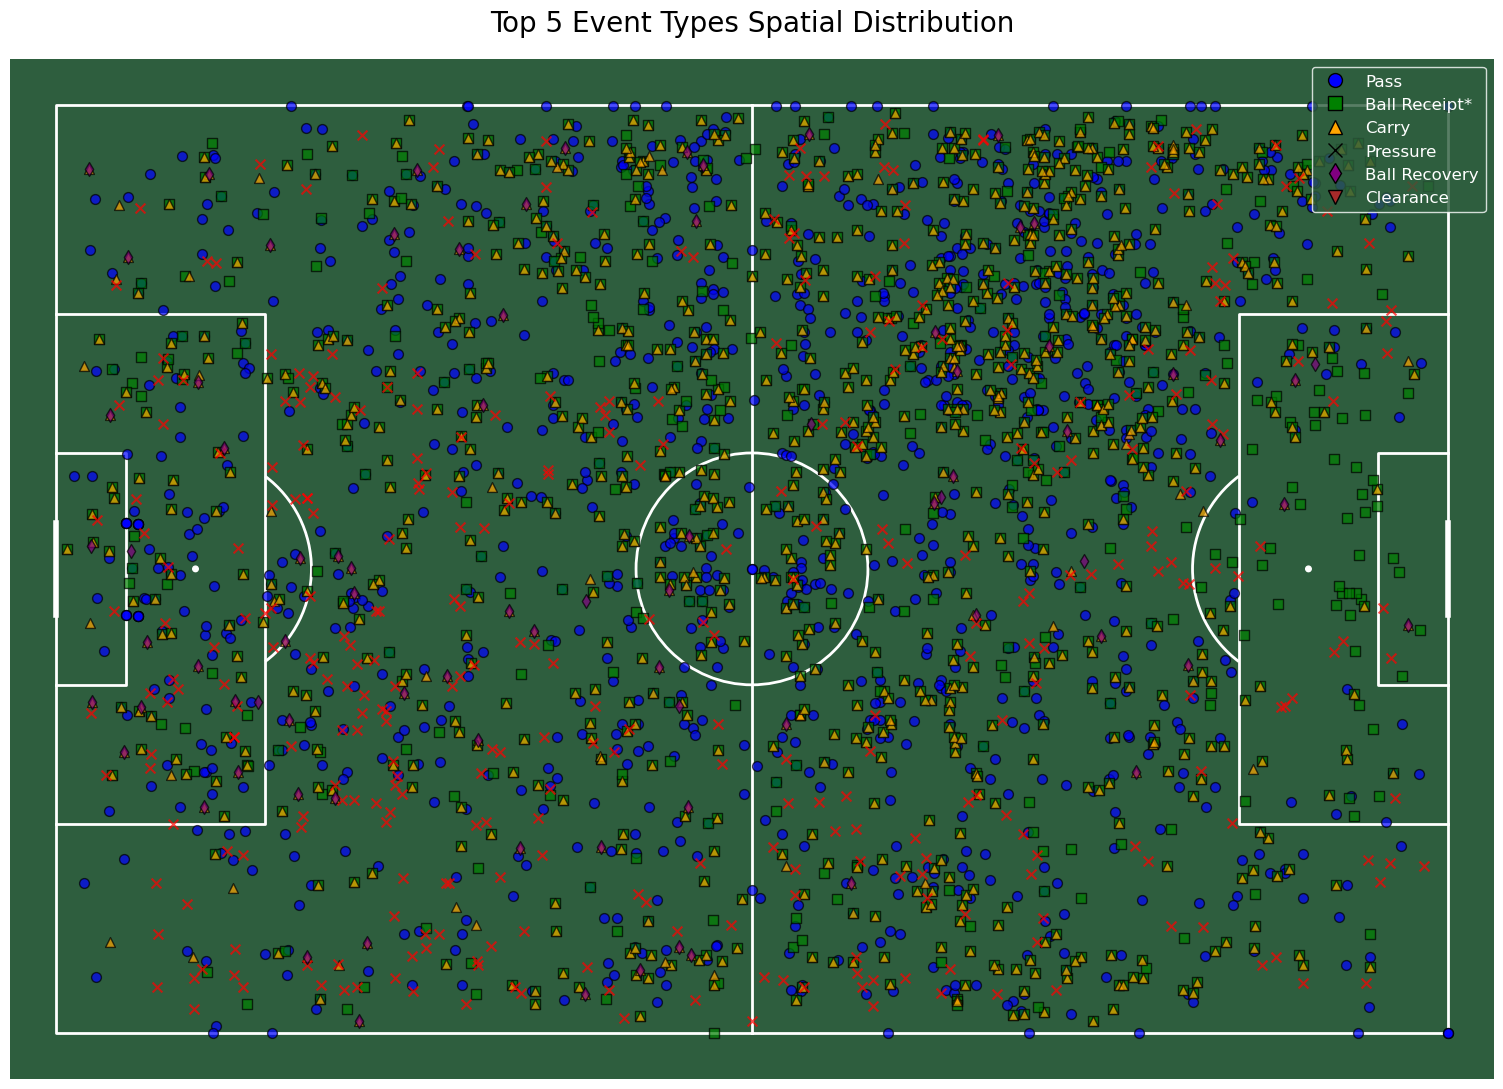

In [21]:
# Create the pitch visualization
pitch = Pitch(pitch_type='statsbomb', pitch_color='#2e5e3e', 
              line_color='white', linewidth=2)
fig, ax = pitch.draw(figsize=(16, 11))

event_colors = {
    'Pass': 'blue', 'Ball Receipt*': 'green', 'Carry': 'orange',
    'Pressure': 'red', 'Ball Recovery': 'purple', 'Clearance': 'brown'
}

event_markers = {
    'Pass': 'o', 'Ball Receipt*': 's', 'Carry': '^',
    'Pressure': 'x', 'Ball Recovery': 'd', 'Clearance': 'v'
}

for event_type in event_types.index.to_list():
    type_events = df_top5[df_top5['event_name'] == event_type]
    for idx, event in type_events.iterrows():
        x, y = event['location']
        ax.scatter(x, y, c=event_colors[event_type], 
                    marker=event_markers[event_type],
                    s=50, alpha=0.7, edgecolors='black')
        

ax.set_title(
    "Top 5 Event Types Spatial Distribution",
    fontsize=20,
    color="black",
    pad=20
)

legend_elements = [
    Line2D(
        [0], [0],
        marker=event_markers[event],
        color='w',
        label=event,
        markerfacecolor=event_colors[event],
        markeredgecolor='black',
        markersize=10,
        linestyle='None'
    )
    for event in event_types.index
    if event in event_colors and event in event_markers
]
legend = ax.legend(
    handles=legend_elements,
    loc='upper right',
    frameon=True,
    facecolor='#2e5e3e',
    edgecolor='white',
    fontsize=12
)

for text in legend.get_texts():
    text.set_color('white')


Q: How can we visualize a team's player dynamics and positional interdependencies?

1. build graph "pass" network from pass events

In [28]:
def extract_name(obj):
    if isinstance(obj, dict):
        return obj.get('name', 'Unknown')
    return str(obj) if obj is not None else 'Unknown'

def construct_pass_network(events_df, team_name):
    # Initialize directed graph
    G = nx.DiGraph()

    # Clean data structure
    events_df['team_name'] = events_df['team'].apply(extract_name)
    events_df['player_name'] = events_df['player'].apply(
        lambda x: extract_name(x) if x is not None else None
    )
    events_df['event_type'] = events_df['type'].apply(extract_name)

    # Filter for team's pass events
    team_passes = events_df[
        (events_df['team_name'] == team_name) &
        (events_df['event_type'] == 'Pass')
    ]

    # Process each pass event
    for idx, pass_event in team_passes.iterrows():
        # Extract passer information
        passer = pass_event.get('player_name')

        # Extract receiver information from nested pass object
        pass_info = pass_event.get('pass', {})
        if isinstance(pass_info, dict):
            recipient_info = pass_info.get('recipient', {})
            receiver = extract_name(recipient_info) if recipient_info else None
        else:
            receiver = None

        # Check if pass was successful (no 'Incomplete' outcome)
        pass_outcome = pass_info.get('outcome') if isinstance(pass_info, dict) else None
        is_successful = not (isinstance(pass_outcome, dict) and
                            pass_outcome.get('name') == 'Incomplete')

        # Add edge to graph for successful passes
        if passer and receiver and is_successful and passer != receiver:
            if G.has_edge(passer, receiver):
                # Increment weight for existing edge
                G[passer][receiver]['weight'] += 1
                G[passer][receiver]['passes'].append(idx)
            else:
                # Create new edge with initial weight
                G.add_edge(passer, receiver, weight=1, passes=[idx])

    return G

In [38]:
match_id = '3773552'
events_path = root_dir / "data" / "events" / f"{match_id}.json"
    
   
with open(events_path, 'r', encoding='utf-8') as f:
    events_data = json.load(f)

events_df = pd.DataFrame(events_data)
match_info = match_df[match_df['match_id']==int(match_id)]

print(f"Match ID: {match_id}")
print(f"Competition: {match_info['competition'].item()}")
print(f"Season: {match_info['season'].item()}")

team1 = "Barcelona"
team2 = "Huesca"

G1 = construct_pass_network(events_df, team1)
G2 = construct_pass_network(events_df, team2)

Match ID: 3773552
Competition: La Liga
Season: 2020/2021


2. plot pass networks to compare teams:
- density
    - measures how interconnected a team's possession structure is, i.e. out of all possible passing connections, which ones are actually used during a match?
    - high density -> team is comfortable with multiple different passing strategies, players are well positioned
    - high density does not necesarily mean a team is better- it's just a different tactic/approach to passing
- centrality
    - degree centrality: counts how many distinct neighbours a node has (distinct passing relationships)
    - PageRank centrality: ranks nodes based on the idea that important nodes are connecred to other important nodes (i.e. a player's score is higher if they receive from already-central players)
    - Betweenness centrality: measures how often a node lies on shortest path between players i.e. how much a player serves as a bridge between players
    - Closeness centrality: inverse of total distance from node i to all other nodes in a fully connected graph (represents a player who can distribute possesion to any teammate in few passes)

In [39]:
def plot_pass_network(G, ax, team_name, max_weight):
    # Network stats
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density = nx.density(G)

    # Layout
    pos = nx.spring_layout(G, seed=42, k=1.3)

    # Edge weights
    weights = np.array([G[u][v]['weight'] for u, v in G.edges()])
    norm = mcolors.Normalize(vmin=0, vmax=max_weight)
    edge_colors = plt.cm.Greys(norm(weights))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=1800,
        node_color="#9ecae1",
        edgecolors="black",
        linewidths=1
    )

    # Edges (dark = frequent)
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color=edge_colors,
        width=2.8,
        alpha=0.9,
        arrows=True,
        arrowstyle='-|>'
    )

    # Labels
    nx.draw_networkx_labels(
        G, pos, ax=ax,
        font_size=10,
        font_weight="bold"
    )

    # Titles
    ax.set_title(team_name, fontsize=18, fontweight="bold", pad=10)
    ax.text(
        0.5, 0.02,
        f"Density: {density:.3f} | Nodes: {num_nodes} | Edges: {num_edges}",
        transform=ax.transAxes,
        ha="center",
        fontsize=12,
        color="gray"
    )

    ax.axis("off")


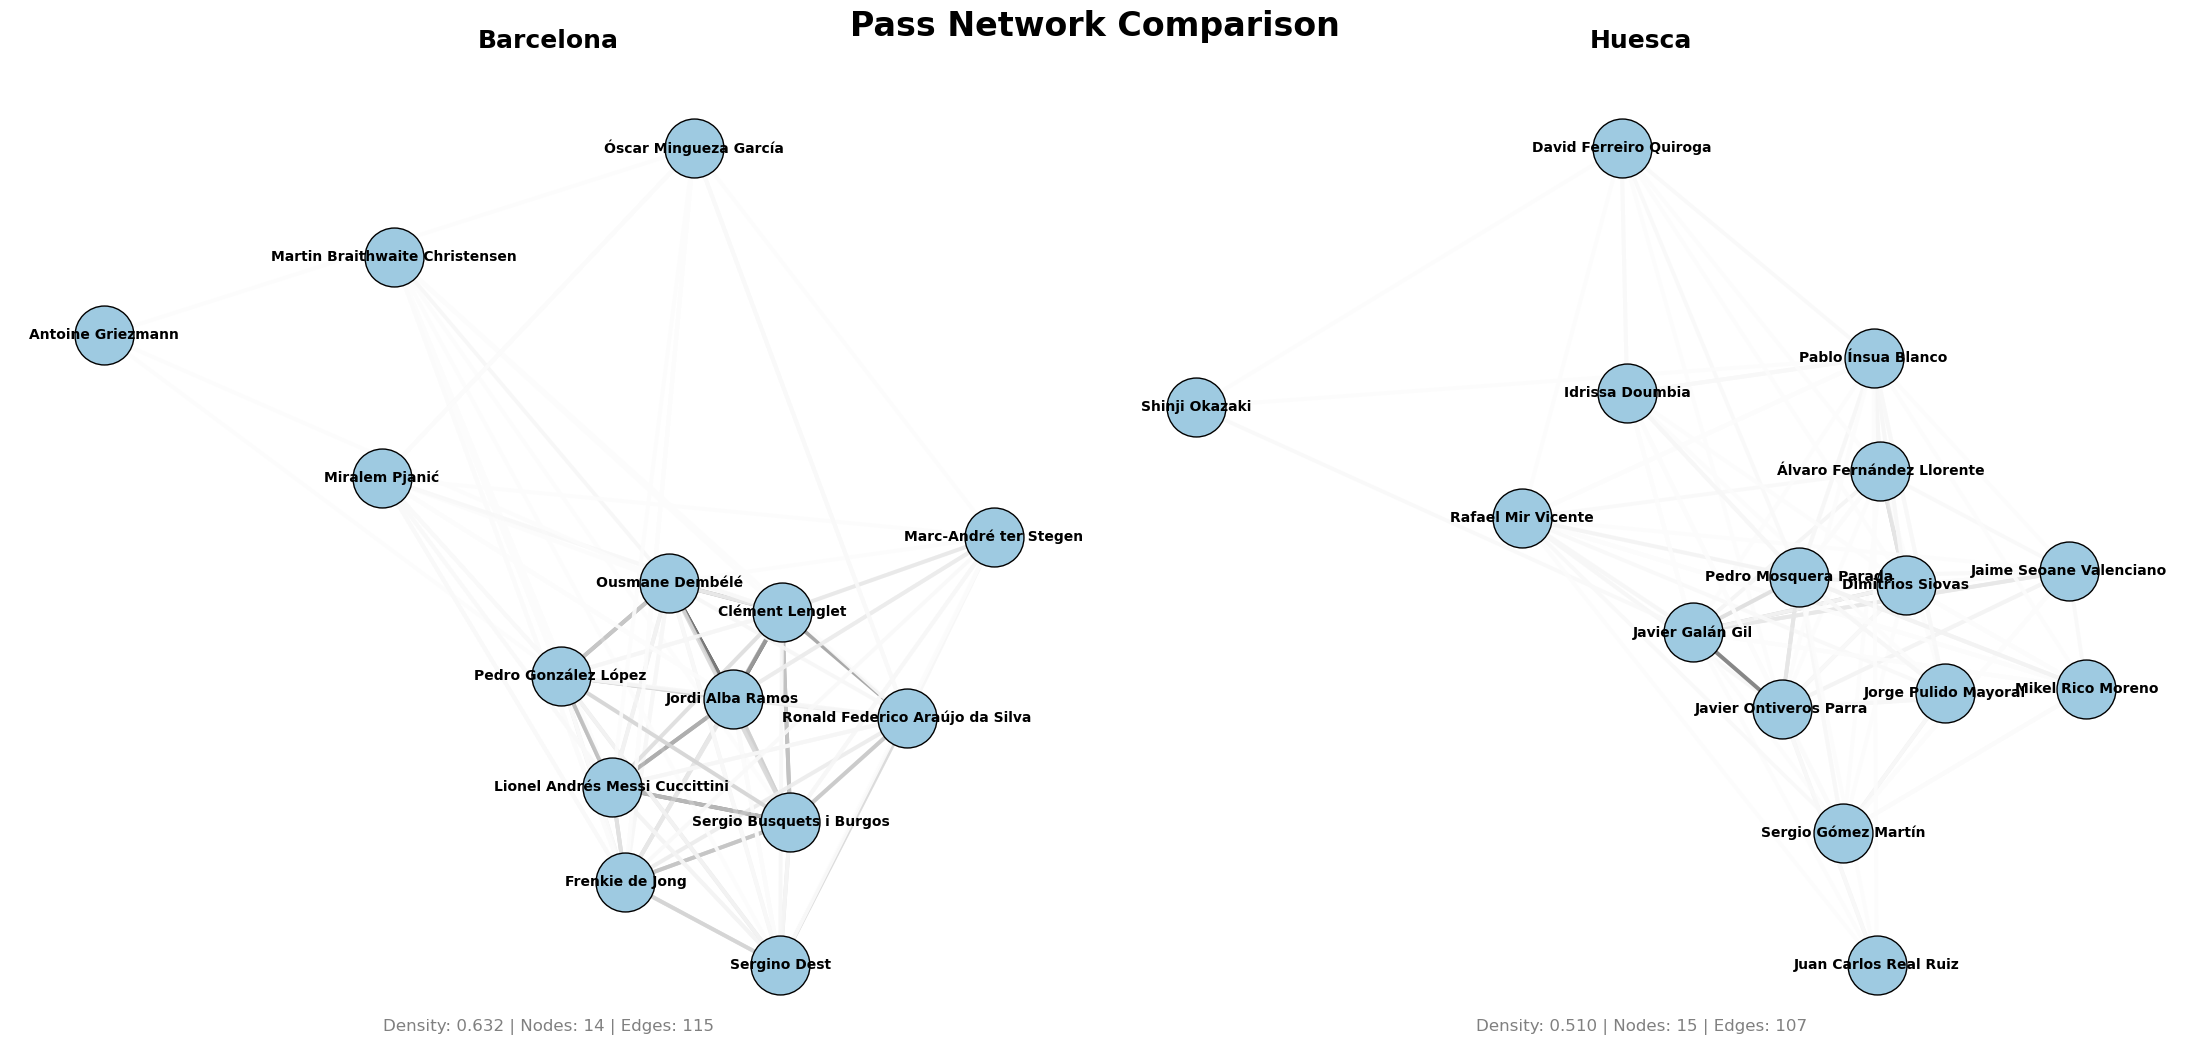

In [40]:
# get max edge weight to normalize the edge colours
max_weight = max(
    max(nx.get_edge_attributes(G1, "weight").values(), default=0),
    max(nx.get_edge_attributes(G2, "weight").values(), default=0)
)

fig, axes = plt.subplots(1, 2, figsize=(22, 11))

plot_pass_network(G1, axes[0], team1, max_weight)
plot_pass_network(G2, axes[1], team2, max_weight)

plt.suptitle(
    "Pass Network Comparison",
    fontsize=24,
    fontweight="bold",
    y=0.96
)

plt.tight_layout()
plt.show()

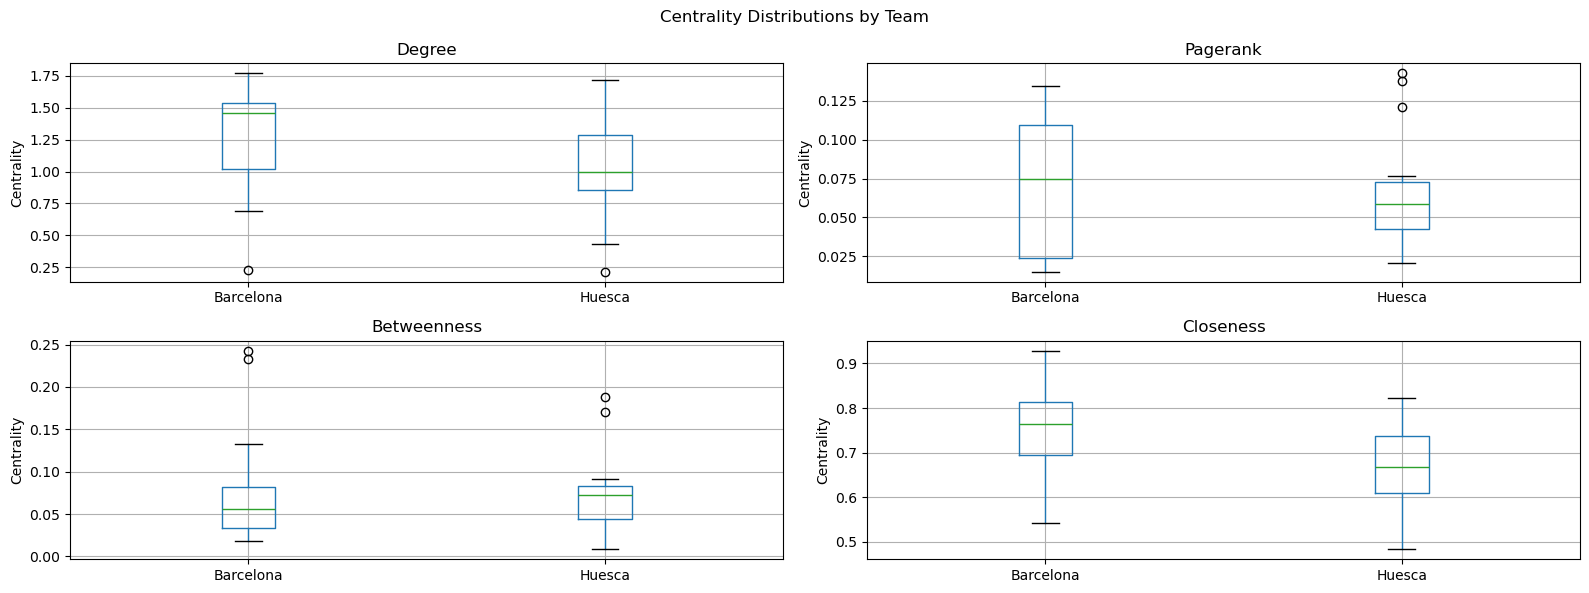

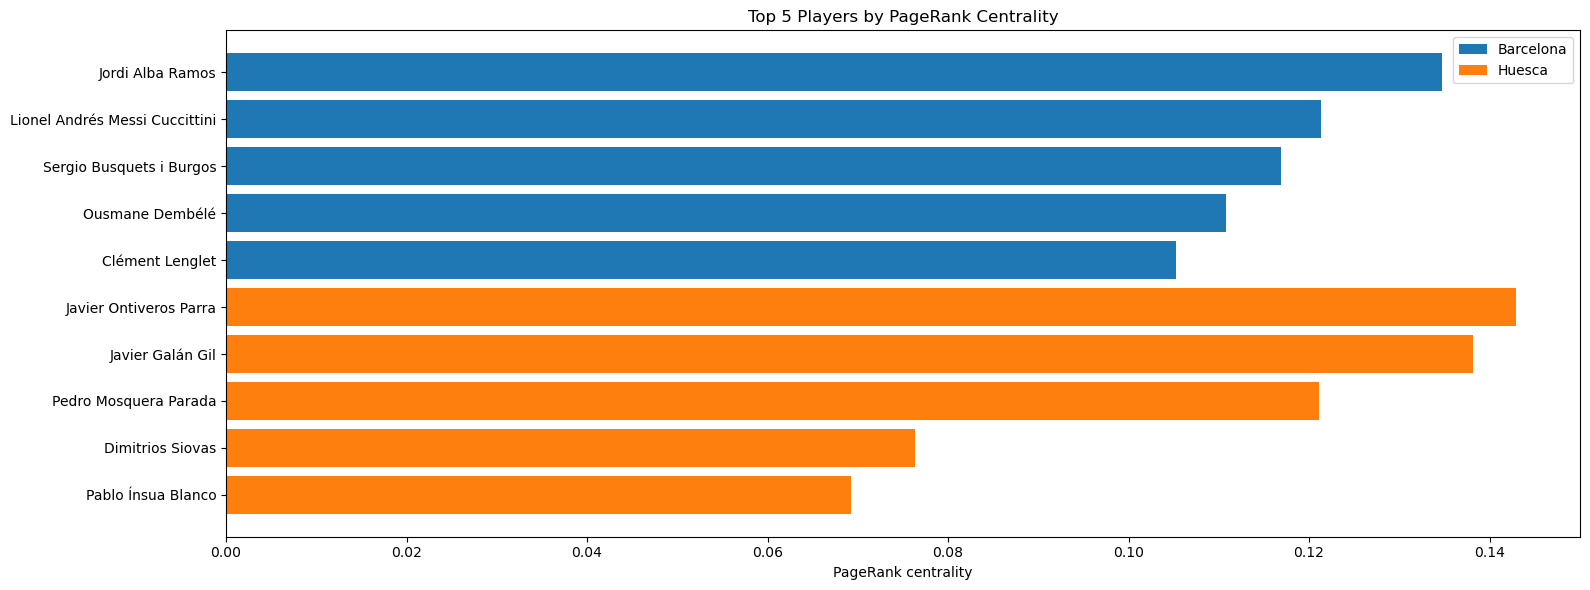

In [52]:
# Calculate centrality measures
def calculate_centralities(pass_network):
    centralities = {}
    
    # Degree centrality - raw connectivity
    centralities['degree'] = nx.degree_centrality(pass_network)
    
    # PageRank - influence-weighted importance  
    centralities['pagerank'] = nx.pagerank(pass_network, weight='weight')
    
    # Betweenness centrality - bridging importance
    centralities['betweenness'] = nx.betweenness_centrality(pass_network, weight='weight')
    
    # Closeness centrality - efficiency of reach
    if nx.is_weakly_connected(pass_network):
        centralities['closeness'] = nx.closeness_centrality(pass_network)
    
    return centralities



C1 = calculate_centralities(G1)
C2 = calculate_centralities(G2)

data = []
for metric in C1:
    data.append(pd.DataFrame({
        'Centrality': list(C1[metric].values()),
        'Team': team1,
        'Metric': metric
    }))
    data.append(pd.DataFrame({
        'Centrality': list(C2[metric].values()),
        'Team': team2,
        'Metric': metric
    }))

df = pd.concat(data)

fig, axes = plt.subplots(2, 2, figsize=(16,6))
metrics = list(C1.keys())

for ax, metric in zip(axes.flatten(), metrics):
    subset = df[df['Metric'] == metric]
    subset.boxplot(column='Centrality', by='Team', ax=ax)
    ax.set_title(metric.capitalize())
    ax.set_xlabel("")
    ax.set_ylabel("Centrality")

plt.suptitle("Centrality Distributions by Team")
plt.tight_layout()
plt.show()


top5_t1 = sorted(C1['pagerank'].items(), key=lambda x: x[1], reverse=True)[:5]
top5_t2 = sorted(C2['pagerank'].items(), key=lambda x: x[1], reverse=True)[:5]
players = [p for p, _ in top5_t1] + [p for p, _ in top5_t2]
values  = [v for _, v in top5_t1] + [v for _, v in top5_t2]

colors = (['tab:blue'] * 5) + (['tab:orange'] * 5)
plt.figure(figsize=(16, 6))
plt.barh(players, values, color=colors)
plt.gca().invert_yaxis()  # top player at top

plt.xlabel("PageRank centrality")
plt.title("Top 5 Players by PageRank Centrality")

# Legend
legend_elements = [
    Patch(facecolor='tab:blue', label=team1),
    Patch(facecolor='tab:orange', label=team2)
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()
